In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from keras import Sequential
import keras
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

2026-06-18 16:30:36.398974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-18 16:30:37.515504: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-18 16:30:39.748013: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

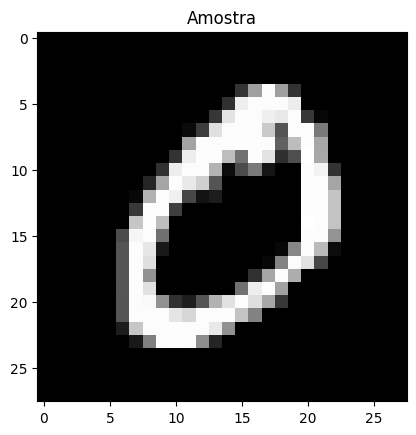

In [4]:
# Ver uma amostra
idx = 1

plt.figure()
plt.imshow(X_train[idx],cmap='gray')
plt.title("Amostra")
plt.show()

In [5]:
# Pré processamento
X_train = (X_train.astype('float32')/255.0)[..., None]
X_test = (X_test.astype('float32')/255.0)[..., None]

# Saída 2 ->[0 0 1 0 0 0 0 0 0 0]
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

Essa notação é um truque muito comum e elegante do NumPy para **adicionar uma nova dimensão** ao seu conjunto de dados.

Vamos quebrar ela em duas partes para entender o que está acontecendo:

* **`...` (Reticências):** Em Python/NumPy, isso se chama *Ellipsis*. Significa "pegue todas as dimensões que já existem no array e mantenha elas intactas".
* **`None`:** Quando usado dentro dos colchetes de um array NumPy, ele atua como um atalho para `np.newaxis`. Ou seja, ele diz "crie uma nova dimensão de tamanho 1 exatamente nesta posição" (que, no seu caso, é no final).

### Por que você precisa disso?

No seu caso (como você está montando uma rede neural com Keras para Visão Computacional), o TensorFlow é bem rigoroso com o formato dos dados. A camada `Conv2D` que você colocou no seu modelo exige que a entrada tenha **4 dimensões**: `(quantidade_de_imagens, altura, largura, canais_de_cor)`.

O dataset MNIST original normalmente é carregado com apenas 3 dimensões:

* **Antes do `[..., None]`:** O formato é `(60000, 28, 28)` — ou seja, 60.000 imagens de tamanho 28x28 pixels. Se você jogar isso direto na rede, o Keras vai dar erro porque falta a dimensão da cor.
* **Depois do `[..., None]`:** O formato passa a ser `(60000, 28, 28, 1)`. Esse `1` no final é a nova dimensão que avisa a rede neural que essas imagens têm apenas 1 canal de cor (são em tons de cinza).

### Alternativas

Se você achar essa notação `[..., None]` um pouco estranha de ler ou explicar, existem outras formas de fazer exatamente a mesma coisa no código, que deixam a intenção mais clara. Todas essas opções dão o mesmo resultado:

* **Usando uma função específica do NumPy:**
`X_train = np.expand_dims(X_train, axis=-1)`
* **Remoldando o array (Reshape):**
`X_train = X_train.reshape(-1, 28, 28, 1)`

In [6]:
# Criação do modelo

model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(16,3,activation='relu'),
    MaxPooling2D(),
    Conv2D(32,3,activation='relu'),
    MaxPooling2D(),
    Flatten(),
    
    Dense(512, activation='relu'),
    Dropout(rate=0.3),
    BatchNormalization(),

    Dense(256, activation='relu'),
    Dropout(rate=0.3),
    BatchNormalization(),

    Dense(128, activation='relu'),
    Dropout(rate=0.3),
    BatchNormalization(),

    Dense(64, activation='relu'),
    Dropout(rate=0.3),
    BatchNormalization(),

    Dense(32, activation='relu'),
    Dropout(rate=0.3),
    BatchNormalization(),

    Dense(16, activation='relu'),
    Dropout(rate=0.3),
    BatchNormalization(),

    Dense(10, activation='softmax')
])

I0000 00:00:1781811043.125971    3039 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 594,202 (2.27 MB)

 Trainable params: 592,186 (2.26 MB)

 Non-trainable params: 2,016 (7.88 KB)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

er = EarlyStopping(
    min_delta=0.001,
    patience=5,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    X_train,y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=512,
    callbacks=[er]
)

Epoch 1/100


2026-06-18 16:30:46.589327: I external/local_xla/xla/service/service.cc:163] XLA service 0x795aa0014a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-18 16:30:46.589352: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-06-18 16:30:46.675930: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-18 16:30:47.461332: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
2026-06-18 16:30:47.782490: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-18 16:30:47.782580: I e

  3/106 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.1176 - loss: 2.7167  

I0000 00:00:1781811056.754603    3168 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 97/106 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2662 - loss: 2.1155

2026-06-18 16:30:58.422345: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-18 16:30:58.422408: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-18 16:30:58.422460: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-18 16:30:58.422476: I external/l

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2786 - loss: 2.0820

2026-06-18 16:31:07.984338: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-18 16:31:07.984397: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-18 16:31:08.541545: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_214', 4 bytes spill stores, 4 bytes spill loads

2026-06-18 16:31:08.932162: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - accuracy: 0.2799 - loss: 2.0785 - val_accuracy: 0.8167 - val_loss: 1.3655
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6974 - loss: 1.0182 - val_accuracy: 0.9615 - val_loss: 0.5328
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8381 - loss: 0.6311 - val_accuracy: 0.9723 - val_loss: 0.2503
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8881 - loss: 0.4470 - val_accuracy: 0.9873 - val_loss: 0.1022
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9148 - loss: 0.3465 - val_accuracy: 0.9813 - val_loss: 0.0964
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9331 - loss: 0.2774 - val_accuracy: 0.9898 - val_loss: 0.0603
Epoch 7/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9392 - loss: 0.2423 - val_accuracy: 0.9833 - val_loss: 0.0825
Epoch 8/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9473 - loss: 0.2146 - val_accuracy: 0.9

In [10]:
accuracy = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

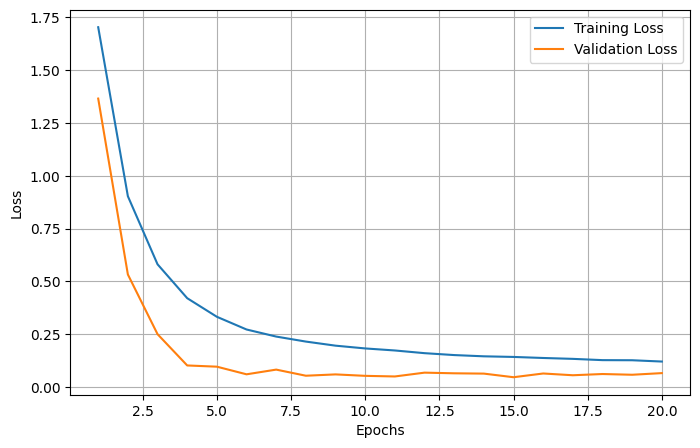

In [11]:
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
preds = np.argmax(model.predict(X_test), axis=1)
y_test_classes = np.argmax(y_test, axis=1)
classes_unicas = np.unique(y_test_classes)

2026-06-18 16:31:23.459433: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-18 16:31:23.459478: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-18 16:31:24.575482: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_157', 24 bytes spill stores, 24 bytes spill loads

2026-06-18 16:31:24.656662: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


Text(0.5, 80.7222222222222, 'Classe Prevista')

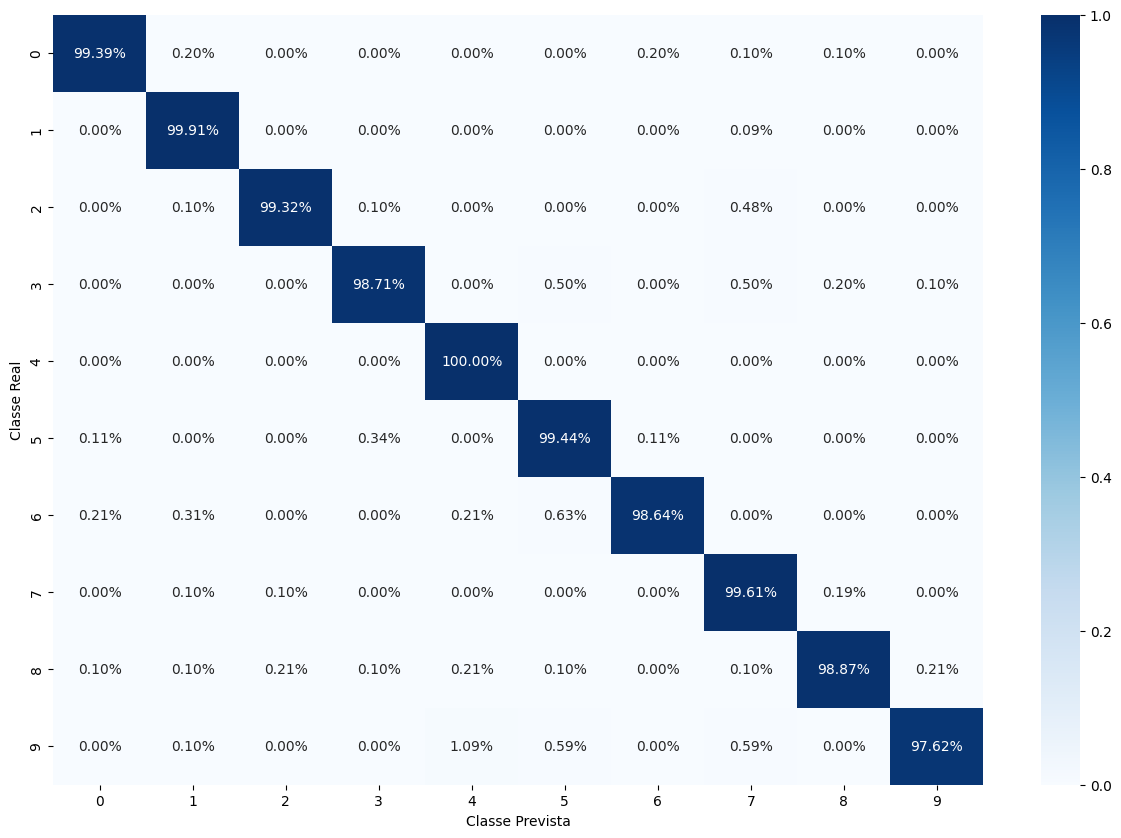

In [13]:
cm = confusion_matrix(y_test_classes, preds, normalize='true')

plt.figure(figsize=(15,10))
sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='.2%',
    xticklabels=classes_unicas, 
    yticklabels=classes_unicas
)

plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')

In [14]:
print(accuracy_score(y_test_classes, preds))

0.9916


In [15]:
print(classification_report(y_test_classes, preds))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       1.00      0.99      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [16]:
# Salvar modelo

model.save("cnn_mnist_model.keras")
#model = tf.keras.models.load_model("cnn_mnist_model.keras")